### Home Task

Titanic - Machine Learning from Disaster

Predict survival


In [1]:
import os
import pandas as pd
# get path current working directory
cwd= os.getcwd() 
path = os.path.join(cwd,'data')


Load train and test data

In [2]:
def get_train_set():
    print ('loading provided train set.')
    fp = os.path.join(path,'train.csv')
    return pd.read_csv(fp)

df_train = get_train_set()
df_train.head()

loading provided train set.


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
def get_test_set():
    print ('loading provided test set.')
    fp = os.path.join(path, 'test.csv')
    return pd.read_csv(fp)

df_test = get_test_set()
df_test.head()

loading provided test set.


,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


train amd test split data

In [4]:
def get_X_train_test(df_train, df_test):
    columns_for_train = df_train.columns.drop(['PassengerId','Survived', 'Name', 'Ticket', 'Cabin'])

    X_train = df_train[columns_for_train]
    X_test = df_test[columns_for_train]
    return X_train, X_test, columns_for_train

X_train, X_test, features = get_X_train_test(df_train, df_test) 

y_train = df_train['Survived']

print("shape train data: ", X_train.shape)
print("shape test data: ", X_test.shape)

X_train.head()

shape train data:  (891, 7)
shape test data:  (418, 7)


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,male,22.0,1,0,7.2500,S
1,1,female,38.0,1,0,71.2833,C
2,3,female,26.0,0,0,7.9250,S
3,1,female,35.0,1,0,53.1000,S
4,3,male,35.0,0,0,8.0500,S


Encoding columns with dtype object

In [5]:

columns_to_encode = X_train.columns[X_train.dtypes == 'object']
columns_to_encode


Index(['Sex', 'Embarked'], dtype='object')

In [6]:
from sklearn.preprocessing import LabelEncoder

In [7]:
def label_encoder(X_train, X_test):    
    print ('label encoding.')
    X_train = X_train.copy()  

    for col in columns_to_encode:
        le = LabelEncoder().fit(X_train[col].astype(str)) 
        X_train[col] = le.transform(X_train[col].astype(str))
        X_test[col] = le.transform(X_test[col].astype(str))
    return X_train,X_test

X_train, X_test = label_encoder(X_train, X_test)
X_train.dtypes

label encoding.


C:\Users\Admin\AppData\Local\Temp\ipykernel_13296\2965084096.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test[col] = le.transform(X_test[col].astype(str))
C:\Users\Admin\AppData\Local\Temp\ipykernel_13296\2965084096.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test[col] = le.transform(X_test[col].astype(str))


Pclass        int64
Sex           int64
Age         float64
SibSp         int64
Parch         int64
Fare        float64
Embarked      int64
dtype: object

handling the missing values NaN

In [8]:
def fill_na(df):
    print ('filling NaN...')
    for col in list(df):
        if df[col].isna().any():
            df[col]= df[col].fillna(0)

fill_na(X_train)
fill_na(X_test) 

X_train.isna().any().any(), X_test.isna().any().any()

filling NaN...
filling NaN...


C:\Users\Admin\AppData\Local\Temp\ipykernel_13296\1156397169.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col]= df[col].fillna(0)


(np.False_, np.False_)

Normalize the data

In [9]:
from sklearn.preprocessing import MinMaxScaler

In [10]:
def normalize(X_train, X_test):
    print ('normalizing.')
    scaler= MinMaxScaler()
    X_train_scaled= scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    return X_train_scaled, X_test_scaled 

X_train_scaled, X_test_scaled  = normalize(X_train, X_test)
type(X_train_scaled)

normalizing.


numpy.ndarray

Train model RandomForestClassifier

In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score

In [12]:
clf = RandomForestClassifier(
    random_state = 0,
    n_estimators=100
).fit(X_train, y_train)

print("train accuracy= {:.3%}".format(clf.score (X_train, y_train)))

train accuracy= 98.204%


In [13]:
y_test = None
train_f1 = f1_score(y_train, clf.predict(X_train_scaled))
print("train set f1= {}".format(train_f1))
if not y_test is None:
    test_f1 = f1_score(y_test, clf.predict(X_test_scaled))
    print("train set f1= {}".format(test_f1))

train set f1= 0.7103658536585366


f:\Anaconda3_Py_Env2\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


Feature importance

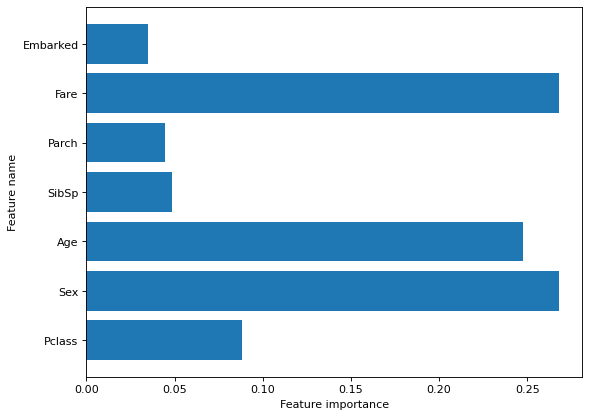

In [14]:
import matplotlib.pyplot as plt
def plot_feature_importances(clf, features):
    plt.figure(figsize=(8, 6), dpi=80)
    plt.barh(features, clf.feature_importances_)
    plt.xlabel("Feature importance")
    plt.ylabel("Feature name")
    plt.show()
    
plot_feature_importances(clf,features)